Chunking + dataset class + dataloader  

SEQ_LEN = 32      # Maximum input context  
TARGET = variable # Remaining tokens until <EOS>  
STRIDE = 16

In [ ]:
import pickle

In [ ]:
with open('/content/encoded_train.pkl','rb') as f:
  encoded_train=pickle.load(f)

with open('/content/encoded_test.pkl','rb') as f:
  encoded_test=pickle.load(f)

with open('/content/encoded_valid.pkl','rb') as f:
  encoded_valid=pickle.load(f)

with open('/content/vocab.pkl','rb') as f:
  vocab=pickle.load(f)

In [ ]:
import torch
from torch.utils.data import Dataset

class DatasetPrep(Dataset):

    def __init__(self, data, vocab,
                 seq_length=32,
                 max_output_length=50,
                 stride=16):

        self.data = data
        self.vocab = vocab
        self.seq_length = seq_length
        self.max_output_length = max_output_length

        # Each element = (row_number, split_position)
        self.indices = []

        for row_idx, row in enumerate(data):
            for i in range(seq_length, len(row), stride):
                self.indices.append((row_idx, i))

    def prep_data(self, row, i):

        # ---------- Encoder ----------
        input_seq = row[i-self.seq_length:i]

        encoder_input = (
            [self.vocab["<BOS>"]]
            + input_seq
            + [self.vocab["<EOS>"]]
        )

        # ---------- Find newline ----------
        nearest_line_end = len(row)

        for j in range(i, len(row)):
            if row[j] == self.vocab["<NEWLINE>"]:
                nearest_line_end = j
                break

        end = min(i + self.max_output_length,
                  nearest_line_end + 1)

        labels = row[i:end]

        # ---------- Decoder ----------
        decoder_input = [self.vocab["<BOS>"]] + labels
        decoder_output = labels + [self.vocab["<EOS>"]]

        return (
            torch.tensor(encoder_input),
            torch.tensor(decoder_input),
            torch.tensor(decoder_output)
        )

    def __getitem__(self, idx):

        row_idx, i = self.indices[idx]

        row = self.data[row_idx]

        return self.prep_data(row, i)

    def __len__(self):
        return len(self.indices)

In [ ]:
from torch.nn.utils.rnn import pad_sequence

PAD = vocab["<PAD>"]

def collate_fn(batch):

    encoder_inputs, decoder_inputs, decoder_outputs = zip(*batch)

    encoder_inputs = pad_sequence(
        encoder_inputs,
        batch_first=True,
        padding_value=PAD
    )

    decoder_inputs = pad_sequence(
        decoder_inputs,
        batch_first=True,
        padding_value=PAD
    )

    decoder_outputs = pad_sequence(
        decoder_outputs,
        batch_first=True,
        padding_value=PAD
    )

    return encoder_inputs, decoder_inputs, decoder_outputs

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_dataset = DatasetPrep(encoded_train, vocab)
valid_dataset = DatasetPrep(encoded_valid, vocab)
test_dataset = DatasetPrep(encoded_test, vocab)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
encoder, decoder_in, decoder_out = next(iter(train_loader))

print(encoder.shape)
print(decoder_in.shape)
print(decoder_out.shape)

output → hidden state at every time step (batch_size, seq_len, hidden_dim)  
hidden → final hidden state for each layer (num_layers, batch_size, hidden_dim)  
cell → final cell state for each layer (num_layers, batch_size, hidden_dim)  

In [ ]:
from torch import nn

class lstmEncoder(nn.Module):
  def __init__(self, vocab_size, hidden_dim, n_layers, dropout):
    super().__init__()
    self.encoder_embedding = nn.Embedding(vocab_size, hidden_dim)
    self.encoder=nn.LSTM(hidden_dim, hidden_dim, n_layers, dropout=dropout, batch_first=True)

  def forward(self,src):
    emb = self.encoder_embedding(src)
    output, (hidden, cell) = self.encoder(emb)

    return hidden, cell

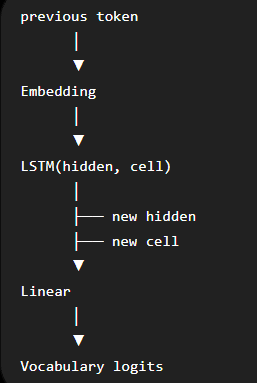

In [ ]:
class lstmDecoder(nn.Module):
  def __init__(self, vocab_size, hidden_dim, n_layers, dropout, linear):
    super().__init__()
    self.decoder_embedding = nn.Embedding(vocab_size, hidden_dim)
    self.decoder=nn.LSTM(hidden_dim, hidden_dim, n_layers, dropout=dropout, batch_first=True)
    self.linear = nn.Linear(hidden_dim, vocab_size)

  def forward(self, input_token, hidden, cell):
    input_token = input_token.unsqueeze(1)
    emb = self.decoder_embedding(input_token)
    output, (h_c, c_c) = self.decoder(emb,(hidden,cell))
    pred = self.linear(output.squeeze(1))

    return pred, h_c, c_c

In [ ]:
class seq2seq(nn.Module):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

  def forward(self, src, target, teacher_forcing_ratio = 0.5):
    batch_size = src.shape[0]
    target_len = target.shape[1]
    target_vocab_size = self.decoder.linear.out_features

    outputs = torch.zeros(batch_size, target_len, target_vocab_size, device=src.device)

    hidden, cell = self.encoder(src)

    input_token = target[:,0] #<SOS>

    for t in range(1, target_len):
      pred, hidden, cell = self.decoder(input_token, hidden, cell)
      outputs[:,t,:] = pred

      teacher_force = torch.rand(1).item() < teacher_forcing_ratio

      top1 = pred.argmax(dim=1)

      input_token = target[:, t] if teacher_force else top1

    return outputs

Loss function - crossEntropyLoss

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=vocab['<PAD>'])

In [ ]:
def token_accuracy(pred, target):
  # ignore <SOS> token
  pred = pred[:,1:,:]
  target = target[:,1:]

  # (B,S,V)->(B,S) for pred to compare pred and target
  pred = pred.argmax(dim=2)

  # mask to ignore indices with padding
  mask = target != vocab['<PAD>']

  # calculate correct tokens
  correct = (pred == target) & mask

  return correct.sum().float() / mask.sum().float()

In [ ]:
epochs=20
vocab_size=len(vocab)
hidden_dim=256
n_layers=2
dropout=0.3
linear=vocab_size
clip=1.0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
encoder = lstmEncoder(vocab_size, hidden_dim, n_layers, dropout)
decoder = lstmDecoder(vocab_size, hidden_dim, n_layers, dropout, linear)
model = seq2seq(encoder, decoder)
model=model.to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
device

In [ ]:
from torch.utils.data import Subset

small_dataset = Subset(train_dataset, range(5000))
small_loader = DataLoader(
    small_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

In [ ]:
print(len(train_loader))

In [ ]:
print(vocab_size)

In [ ]:
!pip install optuna -q

In [ ]:
import optuna
import gc

In [ ]:
from torch.utils.data import DataLoader, Subset

# Small training subset already used in your notebook
small_train_dataset = Subset(
    train_dataset,
    range(min(5000, len(train_dataset)))
)

# Small validation subset
small_valid_dataset = Subset(
    valid_dataset,
    range(min(1000, len(valid_dataset)))
)

small_train_loader = DataLoader(
    small_train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

small_valid_loader = DataLoader(
    small_valid_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
def evaluate_model(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    with torch.no_grad():

        for encoder_inputs, decoder_inputs, decoder_outputs in loader:

            encoder_inputs = encoder_inputs.to(device)
            decoder_inputs = decoder_inputs.to(device)
            decoder_outputs = decoder_outputs.to(device)

            outputs = model(
                encoder_inputs,
                decoder_inputs,
                teacher_forcing_ratio=0.0
            )

            pred = outputs[:, 1:, :].reshape(
                -1, outputs.shape[-1])
            target = decoder_outputs[:, 1:].reshape(-1)

            loss = criterion(pred, target)

            total_loss += loss.item()

            predictions = outputs.argmax(dim=-1)

            # Don't count PAD tokens
            mask = decoder_outputs != vocab["<PAD>"]

            total_correct += (
                (predictions == decoder_outputs) & mask
            ).sum().item()

            total_tokens += mask.sum().item()

    avg_loss = total_loss / len(loader)

    accuracy = (
        total_correct / total_tokens
        if total_tokens > 0
        else 0.0
    )

    return avg_loss, accuracy

In [ ]:
def objective(trial):

    # ==========================
    # 1. Hyperparameters
    # ==========================

    hidden_dim = trial.suggest_categorical(
        "hidden_dim",
        [128, 256, 384, 512]
    )

    n_layers = trial.suggest_int(
        "n_layers",
        1,
        3
    )

    dropout = trial.suggest_float(
        "dropout",
        0.1,
        0.5
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        3e-3,
        log=True
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True
    )

    teacher_forcing_ratio = trial.suggest_float(
        "teacher_forcing_ratio",
        0.3,
        0.7
    )

    # ==========================
    # 2. Build model
    # ==========================

    encoder = lstmEncoder(
        vocab_size,
        hidden_dim,
        n_layers,
        dropout
    )

    decoder = lstmDecoder(
        vocab_size,
        hidden_dim,
        n_layers,
        dropout,
        vocab_size
    )

    model = seq2seq(
        encoder,
        decoder
    ).to(device)

    # ==========================
    # 3. Loss
    # ==========================

    criterion = nn.CrossEntropyLoss(
        ignore_index=vocab["<PAD>"]
    )

    # ==========================
    # 4. Optimizer
    # ==========================

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    # ==========================
    # 5. Scheduler
    # ==========================

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1
    )

    # ==========================
    # 6. Train trial
    # ==========================

    NUM_EPOCHS = 5

    best_val_loss = float("inf")

    for epoch in range(NUM_EPOCHS):

        model.train()

        for encoder_inputs, decoder_inputs, decoder_outputs in small_train_loader:

            encoder_inputs = encoder_inputs.to(device)
            decoder_inputs = decoder_inputs.to(device)
            decoder_outputs = decoder_outputs.to(device)

            optimizer.zero_grad()

            outputs = model(
                encoder_inputs,
                decoder_inputs,
                teacher_forcing_ratio
            )

            loss = criterion(
                outputs.reshape(-1, outputs.shape[-1]),
                decoder_outputs.reshape(-1)
            )

            loss.backward()

            # Prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

        # ==========================
        # Validation
        # ==========================

        val_loss, val_accuracy = evaluate_model(
            model,
            small_valid_loader,
            criterion,
            device
        )

        scheduler.step(val_loss)

        best_val_loss = min(
            best_val_loss,
            val_loss
        )

        # ==========================
        # Optuna pruning
        # ==========================

        trial.report(
            val_loss,
            epoch
        )

        if trial.should_prune():

            del model
            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            raise optuna.TrialPruned()

    # Cleanup GPU memory
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_val_loss

In [ ]:
study = optuna.create_study(
    study_name="lstm_code_completion",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.HyperbandPruner()
)

In [ ]:
study.optimize(
    objective,
    n_trials=10
)

In [ ]:
print("Best validation loss:")
print(study.best_value)

print("\nBest hyperparameters:")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

In [ ]:
df = study.trials_dataframe()

df[
    [
        "number",
        "value",
        "params_hidden_dim",
        "params_n_layers",
        "params_dropout",
        "params_learning_rate",
        "params_weight_decay",
        "params_teacher_forcing_ratio",
        "state"
    ]
]

In [ ]:
best_params = study.best_params

print(best_params)

In [ ]:
PAD_IDX = vocab["<PAD>"]

In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    teacher_forcing_ratio
):
    model.train()

    epoch_loss = 0.0
    epoch_acc = 0.0

    for encoder_inputs, decoder_inputs, decoder_outputs in loader:

        encoder_inputs = encoder_inputs.to(device)
        decoder_inputs = decoder_inputs.to(device)
        decoder_outputs = decoder_outputs.to(device)

        optimizer.zero_grad()

        outputs = model(
            encoder_inputs,
            decoder_inputs,
            teacher_forcing_ratio
        )

        # Match your existing training logic
        pred = outputs[:, 1:, :].reshape(
            -1, outputs.shape[-1]
        )

        target = decoder_outputs[:, 1:].reshape(-1)

        loss = criterion(pred, target)

        # Accuracy
        predictions = outputs[:, 1:, :].argmax(dim=2)
        target_tokens = decoder_outputs[:, 1:]

        mask = target_tokens != PAD_IDX

        correct = (
            (predictions == target_tokens) & mask
        ).sum().float()

        total = mask.sum().float()

        accuracy = correct / total

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += accuracy.item()

    return (
        epoch_loss / len(loader),
        epoch_acc / len(loader)
    )

In [ ]:
def validate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    with torch.no_grad():

        for encoder_inputs, decoder_inputs, decoder_outputs in loader:

            encoder_inputs = encoder_inputs.to(device)
            decoder_inputs = decoder_inputs.to(device)
            decoder_outputs = decoder_outputs.to(device)

            outputs = model(
                encoder_inputs,
                decoder_inputs,
                teacher_forcing_ratio=0.0
            )

            # Ignore timestep 0 because your model
            # does not generate a prediction there
            pred = outputs[:, 1:, :].reshape(
                -1, outputs.shape[-1]
            )

            target = decoder_outputs[:, 1:].reshape(-1)

            loss = criterion(pred, target)

            total_loss += loss.item()

            predictions = outputs[:, 1:, :].argmax(dim=2)
            target_tokens = decoder_outputs[:, 1:]

            mask = target_tokens != PAD_IDX

            total_correct += (
                (predictions == target_tokens) & mask
            ).sum().item()

            total_tokens += mask.sum().item()

    avg_loss = total_loss / len(loader)

    accuracy = (
        total_correct / total_tokens
        if total_tokens > 0
        else 0.0
    )

    return avg_loss, accuracy

In [ ]:
# =========================
# FINAL MODEL
# =========================

hidden_dim = best_params["hidden_dim"]
n_layers = best_params["n_layers"]
dropout = best_params["dropout"]

encoder = lstmEncoder(
    vocab_size,
    hidden_dim,
    n_layers,
    dropout
)

decoder = lstmDecoder(
    vocab_size,
    hidden_dim,
    n_layers,
    dropout,
    vocab_size
)

model = seq2seq(
    encoder,
    decoder
).to(device)

print("Final model created.")
print(f"Hidden dimension : {hidden_dim}")
print(f"LSTM layers      : {n_layers}")
print(f"Dropout          : {dropout}")

In [ ]:
criterion = nn.CrossEntropyLoss(
    ignore_index=vocab["<PAD>"]
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_params["learning_rate"],
    weight_decay=best_params["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [ ]:
NUM_EPOCHS = 20
PATIENCE = 4

best_val_loss = float("inf")
epochs_without_improvement = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

learning_rates = []

BEST_MODEL_PATH = "best_lstm_code_completion.pt"


for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        best_params["teacher_forcing_ratio"]
    )

    # -------------------------
    # Validation
    # -------------------------
    val_loss, val_acc = validate(
        model,
        valid_loader,
        criterion,
        device
    )

    # -------------------------
    # Scheduler
    # -------------------------
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    learning_rates.append(current_lr)

    # -------------------------
    # Print
    # -------------------------
    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Train Acc: {train_acc*100:.2f}% "
        f"| Val Acc: {val_acc*100:.2f}% "
        f"| LR: {current_lr:.6f}"
    )

    # -------------------------
    # Save best model
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_val_loss": best_val_loss,
                "best_params": best_params
            },
            BEST_MODEL_PATH
        )

        print("   ✓ Best model saved")

    else:

        epochs_without_improvement += 1

        print(
            f"   No improvement "
            f"({epochs_without_improvement}/{PATIENCE})"
        )

        if epochs_without_improvement >= PATIENCE:
            print("Early stopping triggered.")
            break

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Token Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    f"Best validation loss: "
    f"{checkpoint['best_val_loss']:.4f}"
)

In [ ]:
test_loss, test_accuracy = validate(
    model,
    test_loader,
    criterion,
    device
)

print("\n===== FINAL LSTM TEST RESULTS =====")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")